# Data Aggregation
## Lab 6 — Retail Sales Analysis by Region

### Aim
To aggregate retail sales data by **region** and **product category** and identify the regions with the highest sales.

### Dataset note
A dedicated retail sales dataset is not available in `sklearn.datasets`. Therefore, the **Wine dataset from sklearn** is used as the base, and simple retail-sales columns are created from it for this lab.

### Tasks
1. Load and explore the dataset.
2. Identify variables used for aggregation.
3. Calculate total sales by region.
4. Visualize sales using bar and pie charts.
5. Find the top-performing region.
6. Calculate sales by region and product category.
7. Create a grouped bar chart.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine

pd.set_option("display.max_columns", None)


## 1. Create the retail sales dataset using sklearn

In [2]:
# Load the Wine dataset from sklearn
wine = load_wine(as_frame=True)
wine_df = wine.frame

# Create a simple retail sales dataset
np.random.seed(42)

df = pd.DataFrame({
    "Transaction_Date": pd.date_range(
        "2025-01-01", periods=len(wine_df), freq="D"
    ),
    "Region": np.random.choice(
        ["North", "South", "East", "West"],
        size=len(wine_df)
    ),
    "Product_Category": wine_df["target"].map({
        0: "Electronics",
        1: "Clothing",
        2: "Grocery"
    }),
    "Quantity_Sold": np.random.randint(1, 11, size=len(wine_df)),
    "Sales_Amount": np.round(
        np.random.uniform(500, 5000, size=len(wine_df)), 2
    )
})

# Save the dataset
df.to_csv("Retail_Sales_Data.csv", index=False)

print("Dataset created successfully.")
display(df.head())


Dataset created successfully.


,Transaction_Date,Region,Product_Category,Quantity_Sold,Sales_Amount
0,2025-01-01,East,Electronics,1,2761.87
1,2025-01-02,West,Electronics,3,3096.07
2,2025-01-03,North,Electronics,5,2716.33
3,2025-01-04,East,Electronics,3,1378.59
4,2025-01-05,East,Electronics,1,3751.03


## 2. Explore the dataset

In [3]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 records:")
display(df.head())

print("\nBasic statistics:")
display(df.describe())


Dataset shape: (178, 5)

Column names:
['Transaction_Date', 'Region', 'Product_Category', 'Quantity_Sold', 'Sales_Amount']

Data types:
Transaction_Date    datetime64[us]
Region                         str
Product_Category               str
Quantity_Sold                int32
Sales_Amount               float64
dtype: object

First 5 records:


,Transaction_Date,Region,Product_Category,Quantity_Sold,Sales_Amount
0,2025-01-01,East,Electronics,1,2761.87
1,2025-01-02,West,Electronics,3,3096.07
2,2025-01-03,North,Electronics,5,2716.33
3,2025-01-04,East,Electronics,3,1378.59
4,2025-01-05,East,Electronics,1,3751.03



Basic statistics:


,Transaction_Date,Quantity_Sold,Sales_Amount
count,178,178.000000,178.000000
mean,2025-03-30 12:00:00,5.140449,2797.602360
min,2025-01-01 00:00:00,1.000000,548.770000
25%,2025-02-14 06:00:00,3.000000,1764.697500
50%,2025-03-30 12:00:00,5.000000,2870.595000
75%,2025-05-13 18:00:00,7.750000,3906.592500
max,2025-06-27 00:00:00,10.000000,4957.270000
std,NaN,2.855749,1332.552985


## 3. Relevant variables

The main variables used for aggregation are:

- **Region** → region of the sale
- **Product_Category** → type of product
- **Quantity_Sold** → number of products sold
- **Sales_Amount** → amount of the sale


## 4. Total sales by region

In [4]:
# Group sales by region
region_sales = (
    df.groupby("Region")["Sales_Amount"]
    .sum()
    .sort_values(ascending=False)
)

print("Total Sales by Region:")
display(region_sales)


Total Sales by Region:


Region
West     148374.57
East     118192.17
South    117197.23
North    114209.25
Name: Sales_Amount, dtype: float64

## 5. Bar chart — Sales by region

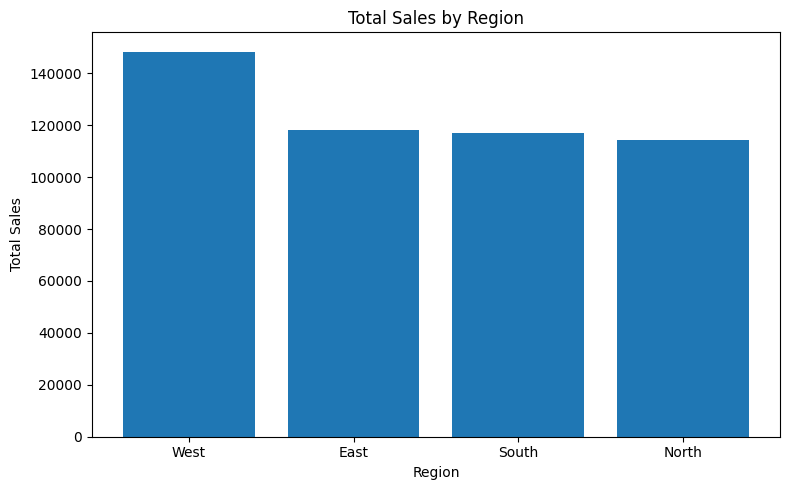

In [5]:
plt.figure(figsize=(8, 5))

plt.bar(region_sales.index, region_sales.values)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()


## 6. Pie chart — Sales distribution by region

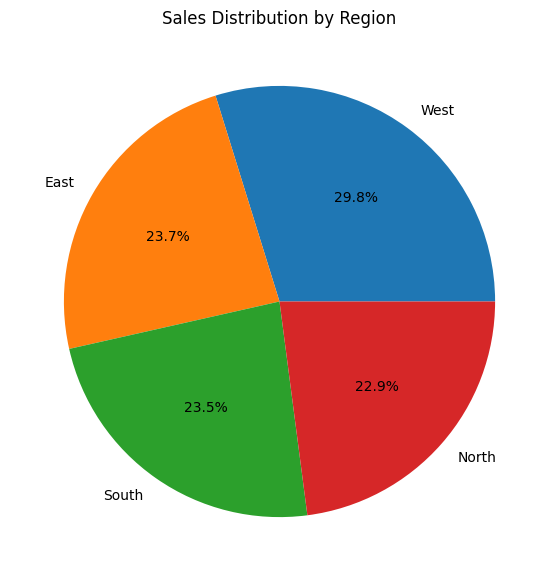

In [6]:
plt.figure(figsize=(7, 7))

plt.pie(
    region_sales.values,
    labels=region_sales.index,
    autopct="%1.1f%%"
)

plt.title("Sales Distribution by Region")
plt.show()


## 7. Identify the top-performing region

In [7]:
top_region = region_sales.idxmax()
top_sales = region_sales.max()

print("Top-performing region:", top_region)
print(f"Total sales in {top_region}: ₹{top_sales:,.2f}")


Top-performing region: West
Total sales in West: ₹148,374.57


## 8. Sales by region and product category

In [8]:
region_category_sales = pd.pivot_table(
    df,
    values="Sales_Amount",
    index="Region",
    columns="Product_Category",
    aggfunc="sum",
    fill_value=0
)

print("Sales by Region and Product Category:")
display(region_category_sales)


Sales by Region and Product Category:


Product_Category,Clothing,Electronics,Grocery
Region,,,
East,28254.71,46271.05,43666.41
North,38584.45,28937.83,46686.97
South,59677.73,43968.69,13550.81
West,52347.03,60242.95,35784.59


## 9. Grouped bar chart

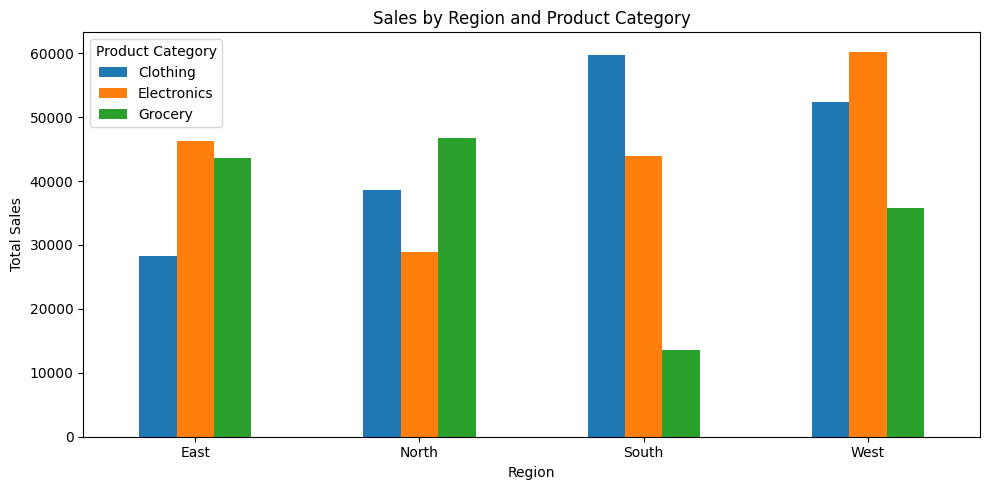

In [9]:
region_category_sales.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Sales by Region and Product Category")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.legend(title="Product Category")
plt.tight_layout()
plt.show()


## Conclusion

The retail sales data was analyzed using pandas aggregation functions.

- Sales were grouped by region.
- Total sales for each region were calculated.
- Bar and pie charts were created.
- The top-performing region was identified.
- Sales were also grouped by region and product category.
- A grouped bar chart was created to compare the combinations.
